# progenitor-score: a worked example on simulated data (Python)

`progenitor-score` scores every cell against the **BoneMarrowMap** atlas (Zeng et al., *Blood Cancer Discovery* 2025;6:307-24) and returns the best-matching bone-marrow state, a group, and a call that says whether a cell is a progenitor you may want to keep (e.g. when extracting monocytes, macrophages and DCs from a public dataset).

This notebook uses **simulated counts with known labels** (`examples/data/`, made by `examples/simulate_counts.py`). It shows how to call the tool and how its calls behave on clean, transitional, out-of-reference and low-depth cells. **It is a plumbing and behaviour check, not an accuracy estimate**: the simulated profiles are averages of the atlas the model was trained on, so real cells will do worse. Accuracy on 9 held-out real donors is in `docs/validation/`.

Requirements: raw counts (integers, not normalised), gene **symbols**, and ideally a QC flag per cell.

In [1]:
from pathlib import Path
import numpy as np, pandas as pd, scipy.io as sio, anndata as ad
import matplotlib.pyplot as plt
import progenitor_score as ps

DATA = Path("data")                                   # examples/data, relative to this notebook
print("progenitor_score", ps.__version__)

progenitor_score 0.1.0


## 1. Load the simulated dataset as an AnnData
A 10x-style sparse matrix (genes x cells), a gene list and a cell table with the **true** labels, which the tool never sees.

In [2]:
M = sio.mmread(DATA / "sim_counts.mtx.gz").tocsr()                       # genes x cells
genes = pd.read_csv(DATA / "sim_genes.tsv", header=None)[0].astype(str).to_numpy()
cells = pd.read_csv(DATA / "sim_cells.csv", index_col="cell")
adata = ad.AnnData(M.T.tocsr().astype(np.float32), obs=cells, var=pd.DataFrame(index=genes))
print(adata)
print("integer counts:", bool(np.allclose(adata.X.data, np.round(adata.X.data))), "| max count:", int(adata.X.max()))
adata.obs.groupby("true_population", sort=False, observed=True).agg(cells=("umis", "size"), median_umis=("umis", "median"), qc_fail=("qc_pass", lambda s: int((~s).sum())))

AnnData object with n_obs × n_vars = 730 × 3497
    obs: 'true_population', 'true_state', 'true_group', 'umis', 'qc_pass'
integer counts: True | max count: 4004


,cells,median_umis,qc_fail
true_population,,,
HSC,50,1308.5,3
Early GMP,70,1566.5,3
GMP-Mono,70,1496.5,2
Pre-cDC,50,1488.5,1
Pre-pDC,40,1824.0,3
Early ProMono,70,1487.0,3
Late ProMono,70,1444.5,2
CD14 Mono,100,1558.0,3
cDC2,50,1814.5,1


## 2. Score the cells
`annotate()` writes the result into `adata.obs` (columns starting `bmps_`) and the model id, thresholds and citation into `adata.uns["progenitor_score"]`. `qc_col` names a boolean column; cells with `False` are not scored. If your gene names are Ensembl ids, pass `symbol_col=` naming the `var` column that holds symbols.

In [3]:
ps.annotate(adata, qc_col="qc_pass")                  # defaults: min_margin=100, min_top1=0
adata.obs[["true_population", "umis", "bmps_bm_state", "bmps_runner_up", "bmps_top1", "bmps_margin", "bmps_bm_group", "bmps_progenitor_call"]].head(8)

,true_population,umis,bmps_bm_state,bmps_runner_up,bmps_top1,bmps_margin,bmps_bm_group,bmps_progenitor_call
cell,,,,,,,,
cell0000,HSC,927,HSC,MPP-MkEry,-330.499011,126.155751,multipotent,uncertain
cell0001,HSC,1714,HSC,MPP-MyLy,-56.836065,306.083361,multipotent,uncertain
cell0002,HSC,2598,HSC,MPP-MyLy,230.910423,324.423990,multipotent,progenitor_review
cell0003,HSC,2299,HSC,MPP-MkEry,-396.666411,266.399775,multipotent,uncertain
cell0004,HSC,1935,HSC,MPP-MyLy,486.293640,685.640441,multipotent,progenitor_review
cell0005,HSC,1458,HSC,MPP-MyLy,809.888620,789.386726,multipotent,progenitor_review
cell0006,HSC,2283,HSC,MPP-MyLy,219.214608,635.124623,multipotent,progenitor_review
cell0007,HSC,751,MPP-MyLy,HSC,-464.754550,20.990365,multipotent,uncertain


The same thing from a terminal, on a saved h5ad, writes a CSV (the second line prints the attribution):

```bash
progenitor-score data.h5ad --symbol-col gene_symbol --qc-col qc_pass -o scores.csv.gz
progenitor-score --cite
```

If you only have a matrix and gene names (no AnnData), use `ps.score_counts(X_cells_by_genes, gene_symbols, cell_names, qc=...)`.

In [4]:
import tempfile
from progenitor_score.cli import main as cli_main
with tempfile.TemporaryDirectory() as d:
    adata.write_h5ad(Path(d) / "x.h5ad"); cli_main([str(Path(d) / "x.h5ad"), "-o", str(Path(d) / "s.csv"), "--qc-col", "qc_pass"])
    cli = pd.read_csv(Path(d) / "s.csv", index_col=0)
print("CLI == annotate():", bool((cli.progenitor_call.to_numpy() == adata.obs.bmps_progenitor_call.astype(str).to_numpy()).all()))

{"progenitor_in": 60, "progenitor_review": 28, "monocyte_precursor": 123, "mature_mnp": 166, "uncertain": 172, "not_progenitor": 154, "not_scored": 27}
CLI == annotate(): True


## 3. What do the calls look like for each simulated population?
Rows are the true populations (never shown to the tool); columns are the calls. `progenitor_in` = GMP-like or DC precursor with a clear margin; `progenitor_review` = HSC/MPP, LMPP, MLP, neutrophil-primed GMP; `monocyte_precursor` = ProMono stages (part of the monocyte continuum); `uncertain` = a progenitor best state without a clear margin.

In [5]:
order = list(adata.obs.true_population.unique())
calls = ["progenitor_in", "progenitor_review", "uncertain", "monocyte_precursor", "mature_mnp", "not_progenitor", "not_scored"]
tab = pd.crosstab(adata.obs.true_population, adata.obs.bmps_progenitor_call.astype(str)).reindex(index=order, columns=calls, fill_value=0)
tab

bmps_progenitor_call,progenitor_in,progenitor_review,uncertain,monocyte_precursor,mature_mnp,not_progenitor,not_scored
true_population,,,,,,,
HSC,0,28,19,0,0,0,3
Early GMP,5,0,62,0,0,0,3
GMP-Mono,31,0,31,6,0,0,2
Pre-cDC,22,0,25,0,2,0,1
Pre-pDC,2,0,34,0,1,0,3
Early ProMono,0,0,1,66,0,0,3
Late ProMono,0,0,0,48,20,0,2
CD14 Mono,0,0,0,2,95,0,3
cDC2,0,0,0,1,48,0,1


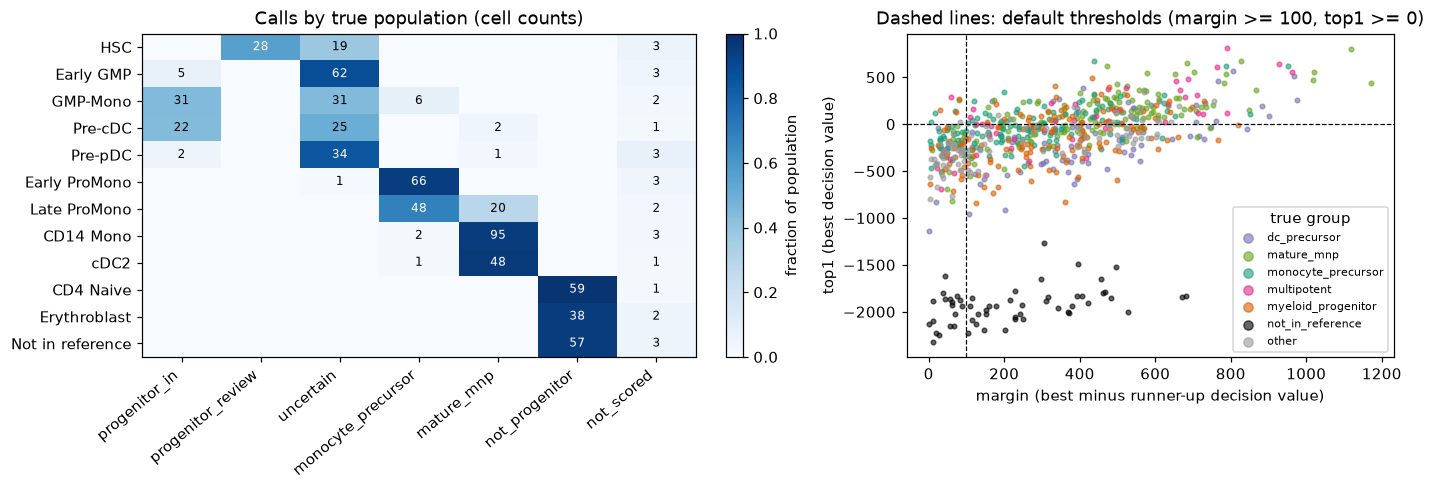

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1.25, 1]})
frac = tab.div(tab.sum(1), axis=0); im = ax[0].imshow(frac.to_numpy(), cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax[0].set_xticks(range(len(calls)), calls, rotation=40, ha="right"); ax[0].set_yticks(range(len(order)), order)
for i in range(frac.shape[0]):
    for j in range(frac.shape[1]):
        if tab.iat[i, j]: ax[0].text(j, i, tab.iat[i, j], ha="center", va="center", fontsize=8, color="white" if frac.iat[i, j] > 0.5 else "black")
ax[0].set_title("Calls by true population (cell counts)"); fig.colorbar(im, ax=ax[0], fraction=0.04, label="fraction of population")
sc = adata.obs[adata.obs.qc_pass]; col = {"myeloid_progenitor": "#d95f02", "dc_precursor": "#7570b3", "monocyte_precursor": "#1b9e77", "multipotent": "#e7298a", "mature_mnp": "#66a61e", "other": "#999999", "not_in_reference": "#000000"}
for g, d in sc.groupby("true_group", observed=True): ax[1].scatter(d.bmps_margin, d.bmps_top1, s=9, alpha=0.6, label=g, color=col.get(g, "#444"))
ax[1].axvline(100, color="k", ls="--", lw=0.8); ax[1].axhline(0, color="k", ls="--", lw=0.8)
ax[1].set_xlabel("margin (best minus runner-up decision value)"); ax[1].set_ylabel("top1 (best decision value)"); ax[1].legend(title="true group", fontsize=7, markerscale=2)
ax[1].set_title("Dashed lines: default thresholds (margin >= 100, top1 >= 0)")
fig.tight_layout(); plt.show()

Reading the plots: transitional populations (Early GMP, GMP-Mono, Pre-cDC, Pre-pDC) are blended with a neighbour state, so many land in `uncertain` rather than `progenitor_in`. That is the intended behaviour: **a call needs a clear lead over the runner-up (`margin`) and a good match to the state (`top1`)**. Cells that match no state, such as the simulated out-of-reference population, have very negative `top1` (right-hand plot, black).

The `top1 >= 0` requirement is the expensive part in marrow-like data. On 9 held-out real bone-marrow donors (`docs/validation/validation_in_progenitor_margin_top1.csv`) the in-progenitor recall at `margin >= 100` is 0.62 (precision 0.89) without a `top1` gate, 0.58 (0.91) with `top1 >= -500` and 0.34 (0.93) with `top1 >= 0`. It is also the guard against forcing non-marrow cells onto progenitor states: on a 210,839-cell non-marrow myeloid test set (macrophage, monocyte and DC cells from tissues), which holds essentially no progenitors, `margin >= 100` alone gives 962 `progenitor_in` calls, `top1 >= -500` gives 153 and `top1 >= 0` gives 12. So: keep the default for tissue data; for bone-marrow-like input you can lower it (`min_top1=-500`) and accept more false calls from unfamiliar cells. Use `margin` and `top1`, not probabilities (saturated for this model).

## 4. State recovery and the threshold trade-off
The default call needs `margin >= 100` **and** `top1 >= 0`. The sweep shows what each requirement costs: `top1 >= 0` removes cells that match no state well (transitional cells, here), at the price of recall.

In [7]:
ok = adata.obs.qc_pass.to_numpy()
rec = (adata.obs.true_state == adata.obs.bmps_bm_state.astype(str))[ok].groupby(adata.obs.true_population[ok], sort=False, observed=True).mean().round(2)
rec.rename("fraction of cells whose best state equals the simulated state").to_frame()

,fraction of cells whose best state equals the simulated state
true_population,
HSC,0.87
Early GMP,0.96
GMP-Mono,0.91
Pre-cDC,0.96
Pre-pDC,0.95
Early ProMono,0.99
Late ProMono,0.68
CD14 Mono,0.98
cDC2,0.98


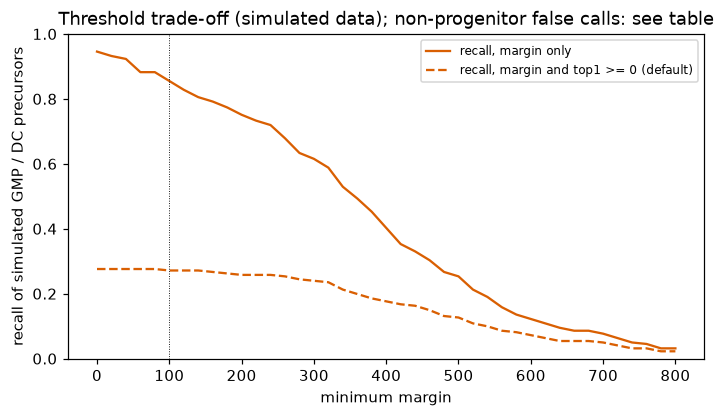

,recall_margin_only,recall_margin_and_top1,false_calls_margin_only,false_calls_margin_and_top1
margin_threshold,,,,
0,0.946,0.276,1,0
100,0.855,0.271,0,0
200,0.751,0.258,0,0
400,0.403,0.176,0,0


In [8]:
o = adata.obs[adata.obs.qc_pass]; truth_in = o.true_group.isin(["myeloid_progenitor", "dc_precursor"]); g_in = o.bmps_bm_group.astype(str).isin(ps.IN_PROGENITOR)
rows = []
for t in np.arange(0, 801, 20):
    both = g_in & (o.bmps_margin >= t) & (o.bmps_top1 >= 0); mar = g_in & (o.bmps_margin >= t)
    rows.append({"margin_threshold": t, "recall_margin_only": (mar & truth_in).sum() / truth_in.sum(), "recall_margin_and_top1": (both & truth_in).sum() / truth_in.sum(),
                 "false_calls_margin_only": int((mar & ~truth_in).sum()), "false_calls_margin_and_top1": int((both & ~truth_in).sum())})
sweep = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(6.6, 3.9)); ax.plot(sweep.margin_threshold, sweep.recall_margin_only, color="#d95f02", label="recall, margin only"); ax.plot(sweep.margin_threshold, sweep.recall_margin_and_top1, color="#d95f02", ls="--", label="recall, margin and top1 >= 0 (default)")
ax.set_xlabel("minimum margin"); ax.set_ylabel("recall of simulated GMP / DC precursors"); ax.axvline(100, color="k", lw=0.6, ls=":"); ax.legend(fontsize=8, loc="upper right"); ax.set_ylim(0, 1)
ax.set_title("Threshold trade-off (simulated data); non-progenitor false calls: see table"); fig.tight_layout(); plt.show()
sweep.iloc[[0, 5, 10, 20]].round(3).set_index("margin_threshold")

## 5. Cases to know about
* **Out-of-reference cells** (here a CD14 monocyte profile with gene identities shuffled) are forced onto the nearest bone-marrow state; the tool is a closed-set classifier. Outside marrow-like tissue, `not_progenitor` is not evidence about lineage.
* **Low-depth cells** (below 500 UMIs here) are skipped when you pass a QC flag; otherwise they would be scored on very little information.
* **Wrong gene identifiers** stop with an error rather than returning nonsense.

In [9]:
oor = adata.obs[(adata.obs.true_population == "Not in reference") & adata.obs.qc_pass]
print("Not-in-reference cells forced onto bone-marrow states:"); print(oor.bmps_bm_state.astype(str).value_counts().head(5).to_string())
print("Not-in-reference cells called progenitor_in or progenitor_review:", int(oor.bmps_progenitor_call.astype(str).isin(["progenitor_in", "progenitor_review"]).sum()), "of", len(oor))
print("QC-failed cells scored:", int((adata.obs.bmps_progenitor_call.astype(str).ne("not_scored") & ~adata.obs.qc_pass).sum()))
bad = ad.AnnData(adata.X, obs=adata.obs[[]], var=pd.DataFrame(index=[f"ENSG{i:011d}" for i in range(adata.n_vars)]))
try: ps.score_anndata(bad)
except ValueError as e: print("Ensembl ids without symbol_col ->", e)

Not-in-reference cells forced onto bone-marrow states:
bmps_bm_state
Mature B              26
Stromal               19
Plasma Cell            6
CD4 Central Memory     2
Immature B             2
Not-in-reference cells called progenitor_in or progenitor_review: 0 of 57
QC-failed cells scored: 0
Ensembl ids without symbol_col -> only 0 of 2997 model genes present: are gene symbols used?


## 6. Checks (the notebook fails if any of these break)

In [10]:
o = adata.obs; call = o.bmps_progenitor_call.astype(str); qc = o.qc_pass
truth_in = o.true_group.isin(["myeloid_progenitor", "dc_precursor"])
assert ((call == "not_scored") == ~qc).all(), "QC flag not respected"
assert (call[qc & ~truth_in & (o.true_group != "not_in_reference")] == "progenitor_in").mean() <= 0.01, "mature / ProMono / T / erythroid cells called progenitor_in"
assert not call[o.true_population == "Not in reference"].isin(["progenitor_in", "progenitor_review"]).any(), "out-of-reference cells called progenitor"
assert rec.drop(["CD4 Naive", "Not in reference"]).median() >= 0.9, "state recovery too low"
assert call[(o.true_population == "HSC") & qc].isin(["progenitor_review", "uncertain"]).mean() >= 0.9, "HSC not routed to review / uncertain"
print("all checks passed")

all checks passed


## 7. Save the scores (the R report compares against this file) and cite

In [11]:
out = adata.obs.filter(like="bmps_").copy(); out.columns = [c.removeprefix("bmps_") for c in out.columns]
out.astype({c: object for c in ["bm_state", "runner_up", "bm_group", "progenitor_call"]}).to_csv(DATA / "sim_scores_python.csv", float_format="%.10g")
print(ps.citation())

Please cite:
  1. Zeng AGX, Iacobucci I, Shah S, Mitchell A, Wong G, Bansal S, Chen D, Gao Q, Kim H, Kennedy JA, Arruda A, Minden MD, Haferlach T, Mullighan CG, Dick JE. Single-cell transcriptional atlas of human hematopoiesis reveals genetic and hierarchy-based determinants of aberrant AML differentiation. Blood Cancer Discov 2025;6:307-24. doi:10.1158/2643-3230.BCD-24-0342
  2. Conor Finlay Lab, Trinity College Dublin. progenitor-score (code MIT; model tables CC BY-NC 4.0).
Model tables: CC BY-NC 4.0 (LICENSE-MODEL.md).
